### FED COMPARISON

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy.stats import wilcoxon, mannwhitneyu


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

os.makedirs('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/FFvSS', exist_ok=True)

df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df1['condition'] = 'starved-starved'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df2['condition'] = 'fed-fed'

df = pd.concat([df1, df2], ignore_index=True)



df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df = df.sort_values(['condition', 'file', 'track_id', 'rel_frame'])


metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['condition', 'file', 'track_id', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']

# Average larvae within each file before stats, so each recording contributes once.
first_interaction_file = (
    first_interaction
    .groupby(['condition', 'file', 'interaction_group', 'rel_frame'])[metrics]
    .mean()
    .reset_index()
)


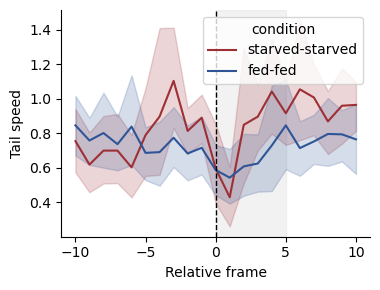

In [2]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='condition',
    hue_order=['starved-starved', 'fed-fed'],
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    errorbar=('ci', 95)
)

plt.axvspan(0, 5, color='0.9', alpha=0.5, zorder=0)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('Tail speed')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/FFvSS/speed.pdf', format='pdf')
plt.show()


In [3]:
# Frames 1-5: average tail speed per file, then independent starved-starved vs fed-fed test
speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_5)
print(speed_1_5.mean())

stat, p = mannwhitneyu(speed_1_5['starved-starved'].dropna(), speed_1_5['fed-fed'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, frames 1-5, starved-starved vs fed-fed: U={stat:.3g}, p={p:.3g}")


condition,fed-fed,starved-starved
file,,
2026-04-28_12-06-18_td8.tracks.feather,0.525864,NaN
2026-04-28_12-11-39_td10.tracks.feather,0.441229,NaN
2026-04-28_15-10-10_td6.tracks.feather,0.528105,NaN
2026-05-12_14-37-56_td2.tracks.feather,NaN,1.119498
2026-05-12_14-40-12_td9.tracks.feather,0.598184,NaN
2026-05-12_14-43-05_td7.tracks.feather,0.683013,NaN
2026-05-18_11-50-46_td8.tracks.feather,0.499041,NaN
2026-05-18_11-54-47_td10.tracks.feather,0.685480,NaN
2026-05-18_11-59-20_td4.tracks.feather,NaN,0.733948


condition
fed-fed            0.670651
starved-starved    0.826882
dtype: float64
Mann-Whitney U test, frames 1-5, starved-starved vs fed-fed: U=67, p=0.157


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24178/3047633186.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


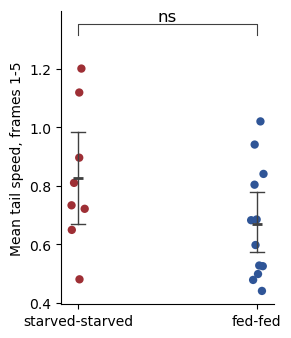

In [4]:
# Plot the values used in the frames 1-5 speed test
speed_1_5_plot = speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved-starved', 'fed-fed'],
    var_name='condition',
    value_name='speed_tail'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=speed_1_5_plot,
    x='condition',
    y='speed_tail',
    order=['starved-starved', 'fed-fed'],
    hue='condition',
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=speed_1_5_plot,
    x='condition',
    y='speed_tail',
    order=['starved-starved', 'fed-fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = speed_1_5_plot['speed_tail'].max()
ymin = speed_1_5_plot['speed_tail'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean tail speed, frames 1-5')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/FFvSS/speed_mean.pdf', format='pdf')
plt.show()


In [5]:
# Frames 1-5 after contact compared with frames -5 to -1 before contact, tail speed
pre_speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(-5, -1)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

post_speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

change_speed_1_5 = post_speed_1_5 - pre_speed_1_5

display(pd.concat({'pre': pre_speed_1_5, 'post': post_speed_1_5, 'post_minus_pre': change_speed_1_5}, axis=1))
print('Mean pre:')
print(pre_speed_1_5.mean())
print('\nMean post:')
print(post_speed_1_5.mean())
print('\nMean post - pre:')
print(change_speed_1_5.mean())

starved_starved_pairs = pd.concat([pre_speed_1_5['starved-starved'], post_speed_1_5['starved-starved']], axis=1, keys=['pre', 'post']).dropna()
stat, p_starved_starved = wilcoxon(starved_starved_pairs['pre'], starved_starved_pairs['post'])
print(f"starved-starved pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_starved_starved:.3g}")

fed_fed_pairs = pd.concat([pre_speed_1_5['fed-fed'], post_speed_1_5['fed-fed']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_fed = wilcoxon(fed_fed_pairs['pre'], fed_fed_pairs['post'])
print(f"fed-fed pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_fed:.3g}")

stat, change_p = mannwhitneyu(change_speed_1_5['starved-starved'].dropna(), change_speed_1_5['fed-fed'].dropna(), alternative='two-sided')
print(f"Change score, tail speed starved-starved vs fed-fed, frames 1-5: U={stat:.3g}, p={change_p:.3g}")


pre                      post  \
condition                                 fed-fed starved-starved   fed-fed   
file                                                                          
2026-04-28_12-06-18_td8.tracks.feather   0.462360             NaN  0.525864   
2026-04-28_12-11-39_td10.tracks.feather  1.049770             NaN  0.441229   
2026-04-28_15-10-10_td6.tracks.feather   0.830654             NaN  0.528105   
2026-05-12_14-37-56_td2.tracks.feather        NaN        0.768671       NaN   
2026-05-12_14-40-12_td9.tracks.feather   0.994959             NaN  0.598184   
2026-05-12_14-43-05_td7.tracks.feather   0.888120             NaN  0.683013   
2026-05-18_11-50-46_td8.tracks.feather   0.535840             NaN  0.499041   
2026-05-18_11-54-47_td10.tracks.feather  0.901716             NaN  0.685480   
2026-05-18_11-59-20_td4.tracks.feather        NaN        0.622170       NaN   
2026-05-18_12-00-57_td1.tracks.feather        NaN        1.187068       NaN   
2026-05-18_15-07-28_td20.tracks.feather  0.718987             NaN  1.020764   
2026-05-19_12-21-24_td1.tracks.feather        NaN        0.812966       NaN   
2026-05-19_12-27-40_td7.tracks.feather   0.420248             NaN  0.804411   
2026-06-05_12-00-53_td7.tracks.feather   0.630057             NaN  0.478862   
2026-06-05_12-02-47_td6.tracks.feather   0.377963             NaN  0.941589   
2026-06-05_12-09-45_td1.tracks.feather        NaN        0.754199       NaN   
2026-06-22_12-04-28_td11.tracks.feather       NaN        1.129584       NaN   
2026-06-22_12-04-58_td9.tracks.feather        NaN        1.413668       NaN   
2026-06-23_15-44-45_td4.tracks.feather   0.714814             NaN  0.841268   
2026-06-23_15-46-29_td8.tracks.feather        NaN        0.505302       NaN   

                                                        post_minus_pre  \
condition                               starved-starved        fed-fed   
file                                                                     
2026-04-28_12-06-18_td8.tracks.feather              NaN       0.063504   
2026-04-28_12-11-39_td10.tracks.feather             NaN      -0.608541   
2026-04-28_15-10-10_td6.tracks.feather              NaN      -0.302548   
2026-05-12_14-37-56_td2.tracks.feather         1.119498            NaN   
2026-05-12_14-40-12_td9.tracks.feather              NaN      -0.396775   
2026-05-12_14-43-05_td7.tracks.feather              NaN      -0.205106   
2026-05-18_11-50-46_td8.tracks.feather              NaN      -0.036800   
2026-05-18_11-54-47_td10.tracks.feather             NaN      -0.216236   
2026-05-18_11-59-20_td4.tracks.feather         0.733948            NaN   
2026-05-18_12-00-57_td1.tracks.feather         0.810640            NaN   
2026-05-18_15-07-28_td20.tracks.feather             NaN       0.301777   
2026-05-19_12-21-24_td1.tracks.feather         0.649907            NaN   
2026-05-19_12-27-40_td7.tracks.feather              NaN       0.384163   
2026-06-05_12-00-53_td7.tracks.feather              NaN      -0.151195   
2026-06-05_12-02-47_td6.tracks.feather              NaN       0.563626   
2026-06-05_12-09-45_td1.tracks.feather         0.480958            NaN   
2026-06-22_12-04-28_td11.tracks.feather        0.721980            NaN   
2026-06-22_12-04-58_td9.tracks.feather         1.201368            NaN   
2026-06-23_15-44-45_td4.tracks.feather              NaN       0.126454   
2026-06-23_15-46-29_td8.tracks.feather         0.896755            NaN   

                                                         
condition                               starved-starved  
file                                                     
2026-04-28_12-06-18_td8.tracks.feather              NaN  
2026-04-28_12-11-39_td10.tracks.feather             NaN  
2026-04-28_15-10-10_td6.tracks.feather              NaN  
2026-05-12_14-37-56_td2.tracks.feather         0.350827  
2026-05-12_14-40-12_td9.tracks.feather              NaN  
2026-05-12_14-43-05_td7.tracks.feather              NaN  
202

Mean pre:
condition
fed-fed            0.710457
starved-starved    0.899204
dtype: float64

Mean post:
condition
fed-fed            0.670651
starved-starved    0.826882
dtype: float64

Mean post - pre:
condition
fed-fed           -0.039806
starved-starved   -0.072322
dtype: float64
starved-starved pre vs post, tail speed frames 1-5: W=13, p=0.547
fed-fed pre vs post, tail speed frames 1-5: W=32, p=0.622
Change score, tail speed starved-starved vs fed-fed, frames 1-5: U=44, p=0.792


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24178/2903483439.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


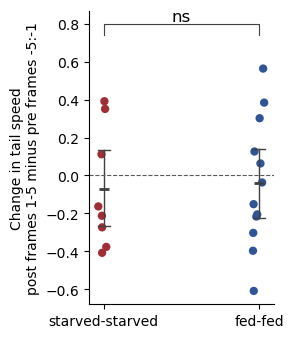

In [6]:
# Plot the values used in the frames 1-5 speed change-score test
change_speed_1_5_plot = change_speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved-starved', 'fed-fed'],
    var_name='condition',
    value_name='speed_change'
)

if change_p < 0.001:
    stars = '***'
elif change_p < 0.01:
    stars = '**'
elif change_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=change_speed_1_5_plot,
    x='condition',
    y='speed_change',
    order=['starved-starved', 'fed-fed'],
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    hue='condition',
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=change_speed_1_5_plot,
    x='condition',
    y='speed_change',
    order=['starved-starved', 'fed-fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

plt.axhline(0, color='0.35', linewidth=0.8, linestyle='--')

ymax = change_speed_1_5_plot['speed_change'].max()
ymin = change_speed_1_5_plot['speed_change'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Change in tail speed\npost frames 1-5 minus pre frames -5:-1')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/FFvSS/speed_baseline_change.pdf', format='pdf')
plt.show()


In [7]:
# Test whether each condition changes from before to after contact, frames 1-5
starved_starved_pairs = pd.concat([pre_speed_1_5['starved-starved'], post_speed_1_5['starved-starved']], axis=1, keys=['pre', 'post']).dropna()
stat, p_starved_starved = wilcoxon(starved_starved_pairs['pre'], starved_starved_pairs['post'])
print(f"starved-starved pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_starved_starved:.3g}")
print(f"starved-starved mean change: {change_speed_1_5['starved-starved'].mean():.3g}")

fed_fed_pairs = pd.concat([pre_speed_1_5['fed-fed'], post_speed_1_5['fed-fed']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_fed = wilcoxon(fed_fed_pairs['pre'], fed_fed_pairs['post'])
print(f"fed-fed pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_fed:.3g}")
print(f"fed-fed mean change: {change_speed_1_5['fed-fed'].mean():.3g}")


starved-starved pre vs post, tail speed frames 1-5: W=13, p=0.547
starved-starved mean change: -0.0723
fed-fed pre vs post, tail speed frames 1-5: W=32, p=0.622
fed-fed mean change: -0.0398


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24178/3970767022.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24178/3970767022.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


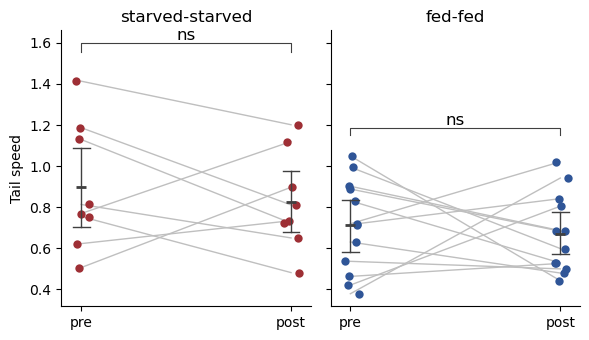

In [8]:
# Plot pre vs post tail speed within each condition, frames 1-5
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)

for ax, condition, color, test_p in zip(
    axes,
    ['starved-starved', 'fed-fed'],
    ['#9E2F35', '#2F5597'],
    [p_starved_starved, p_fed_fed]
):
    plot_data = pd.DataFrame({
        'file': pre_speed_1_5.index,
        'pre': pre_speed_1_5[condition],
        'post': post_speed_1_5[condition]
    }).dropna()
    long_plot_data = plot_data.melt(
        id_vars='file',
        value_vars=['pre', 'post'],
        var_name='time',
        value_name='speed_tail'
    )

    if test_p < 0.001:
        stars = '***'
    elif test_p < 0.01:
        stars = '**'
    elif test_p < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    for _, row in plot_data.iterrows():
        ax.plot([0, 1], [row['pre'], row['post']], color='0.75', linewidth=1, zorder=1)

    sns.stripplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        color=color,
        size=6,
        jitter=0.04,
        ax=ax,
        zorder=2
    )

    sns.pointplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        errorbar=('ci', 95),
        color='0.25',
        markers='_',
        linestyles='none',
        capsize=0.08,
        err_kws={'linewidth': 1},
        join=False,
        ax=ax
    )

    ymax = long_plot_data['speed_tail'].max()
    ymin = long_plot_data['speed_tail'].min()
    y_range = ymax - ymin if ymax > ymin else 1
    y = ymax + y_range * 0.15
    h = y_range * 0.05
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
    ax.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

    ax.set_title(condition)
    ax.set_xlabel('')
    ax.set_ylabel('Tail speed' if condition == 'starved-starved' else '')

sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/FFvSS/speed_baseline_change_within_condition.pdf', format='pdf')
plt.show()


In [9]:
# Frames 1-10: average tail speed per file, then independent starved-starved vs fed-fed test
speed_1_10 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 10)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_10)
print(speed_1_10.mean())

stat, p = mannwhitneyu(speed_1_10['starved-starved'].dropna(), speed_1_10['fed-fed'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, frames 1-10, starved-starved vs fed-fed: U={stat:.3g}, p={p:.3g}")


condition,fed-fed,starved-starved
file,,
2026-04-28_12-06-18_td8.tracks.feather,0.697377,NaN
2026-04-28_12-11-39_td10.tracks.feather,0.552430,NaN
2026-04-28_15-10-10_td6.tracks.feather,0.668003,NaN
2026-05-12_14-37-56_td2.tracks.feather,NaN,1.053093
2026-05-12_14-40-12_td9.tracks.feather,0.645788,NaN
2026-05-12_14-43-05_td7.tracks.feather,0.570078,NaN
2026-05-18_11-50-46_td8.tracks.feather,0.655330,NaN
2026-05-18_11-54-47_td10.tracks.feather,0.774628,NaN
2026-05-18_11-59-20_td4.tracks.feather,NaN,0.640459


condition
fed-fed            0.717666
starved-starved    0.899198
dtype: float64
Mann-Whitney U test, frames 1-10, starved-starved vs fed-fed: U=77, p=0.0252


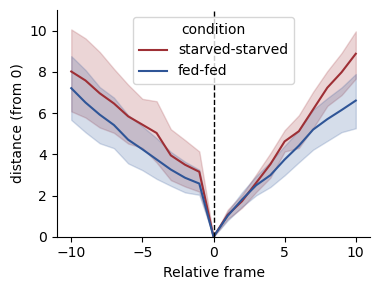

In [10]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='condition',
    hue_order=['starved-starved', 'fed-fed'],
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    errorbar=('ci', 95)
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('distance (from 0)')
sns.despine()
plt.tight_layout()
plt.ylim(0,11)
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/FFvSS/distance_from_0.pdf', format='pdf')
plt.show()


In [11]:
# Frames 1-5: average distance_from_0 per file, then independent starved-starved vs fed-fed test
distance_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_5)
print(distance_1_5.mean())

stat, p = mannwhitneyu(distance_1_5['starved-starved'].dropna(), distance_1_5['fed-fed'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, distance_from_0 frames 1-5, starved-starved vs fed-fed: U={stat:.3g}, p={p:.3g}")


condition,fed-fed,starved-starved
file,,
2026-04-28_12-06-18_td8.tracks.feather,1.555420,NaN
2026-04-28_12-11-39_td10.tracks.feather,2.573323,NaN
2026-04-28_15-10-10_td6.tracks.feather,1.707575,NaN
2026-05-12_14-37-56_td2.tracks.feather,NaN,2.764659
2026-05-12_14-40-12_td9.tracks.feather,2.163309,NaN
2026-05-12_14-43-05_td7.tracks.feather,1.992436,NaN
2026-05-18_11-50-46_td8.tracks.feather,2.663494,NaN
2026-05-18_11-54-47_td10.tracks.feather,1.919286,NaN
2026-05-18_11-59-20_td4.tracks.feather,NaN,2.107330


condition
fed-fed            2.409509
starved-starved    2.709921
dtype: float64
Mann-Whitney U test, distance_from_0 frames 1-5, starved-starved vs fed-fed: U=62, p=0.305


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24178/942816567.py:35: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


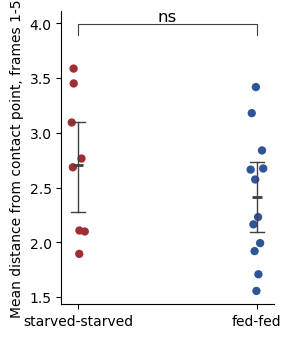

In [12]:
# Plot the values used in the frames 1-5 distance_from_0 test
_, distance_p = mannwhitneyu(distance_1_5['starved-starved'].dropna(), distance_1_5['fed-fed'].dropna(), alternative='two-sided')

distance_1_5_plot = distance_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved-starved', 'fed-fed'],
    var_name='condition',
    value_name='distance_from_0'
)

if distance_p < 0.001:
    stars = '***'
elif distance_p < 0.01:
    stars = '**'
elif distance_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=distance_1_5_plot,
    x='condition',
    y='distance_from_0',
    order=['starved-starved', 'fed-fed'],
    hue='condition',
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_5_plot,
    x='condition',
    y='distance_from_0',
    order=['starved-starved', 'fed-fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_5_plot['distance_from_0'].max()
ymin = distance_1_5_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-5')
sns.despine()
plt.tight_layout()
plt.show()


condition,fed-fed,starved-starved
file,,
2026-04-28_12-06-18_td8.tracks.feather,2.493947,NaN
2026-04-28_12-11-39_td10.tracks.feather,4.332201,NaN
2026-04-28_15-10-10_td6.tracks.feather,2.990397,NaN
2026-05-12_14-37-56_td2.tracks.feather,NaN,5.274250
2026-05-12_14-40-12_td9.tracks.feather,2.771458,NaN
2026-05-12_14-43-05_td7.tracks.feather,3.257548,NaN
2026-05-18_11-50-46_td8.tracks.feather,4.536210,NaN
2026-05-18_11-54-47_td10.tracks.feather,3.764750,NaN
2026-05-18_11-59-20_td4.tracks.feather,NaN,3.584553


condition
fed-fed            4.011606
starved-starved    4.893242
dtype: float64
Mann-Whitney U test, distance_from_0 frames 1-10, starved-starved vs fed-fed: U=68, p=0.135


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24178/2936773608.py:47: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


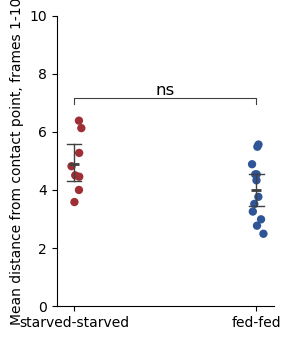

In [13]:
# Frames 1-10: average distance_from_0 per file, then independent starved-starved vs fed-fed test
distance_1_10 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 10)]
    .groupby(['file', 'condition'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_10)
print(distance_1_10.mean())

stat, p = mannwhitneyu(distance_1_10['starved-starved'].dropna(), distance_1_10['fed-fed'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, distance_from_0 frames 1-10, starved-starved vs fed-fed: U={stat:.3g}, p={p:.3g}")

# Plot the values used in the frames 1-10 distance_from_0 test
distance_1_10_plot = distance_1_10.reset_index().melt(
    id_vars='file',
    value_vars=['starved-starved', 'fed-fed'],
    var_name='condition',
    value_name='distance_from_0'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=distance_1_10_plot,
    x='condition',
    y='distance_from_0',
    order=['starved-starved', 'fed-fed'],
    hue='condition',
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_10_plot,
    x='condition',
    y='distance_from_0',
    order=['starved-starved', 'fed-fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_10_plot['distance_from_0'].max()
ymin = distance_1_10_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-10')
plt.ylim(0, 10)
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/FFvSS/distance_from_0_mean.pdf', format='pdf')
plt.show()
